# AES DPA

**Generating power traces for AES using Verilog simulation VCD and breaking AES through Differential Power Analysis (DPA)**

You will be given a set of power traces taken during
AES-ECB executions (extracted via simulation VCD dump) with the associated plaintext and ciphertext pairs, and
you will be asked to extract the 128-bit secret key via DPA.

---

## 1 Download provided files

This step imports the required RTL files for AES and its testbench into our environment.

Gdown is a package to download Google Drive folders. All our required AES files are on google drive, and this will be used to pull in the required files.

### 1.1 Install gdown package

In [1]:
!pip install gdown

Defaulting to user installation because normal site-packages is not writeable


### 1.2 Download the files from google drive using gdown

The google drive folder, which we are going to download using gdown, is [here](https://drive.google.com/drive/folders/1pPd6e4pJM7x8eoPraKG3YzYTP1fGCtPO).

In [2]:
import os
import gdown

# Local persistent disk: only download once. Re-downloading every run would
# overwrite the testbench path fix (DPA_AES/... instead of the instructor's
# /content/... path, which only exists on Colab) with the original, broken
# copy every time this cell re-runs.
if not os.path.exists("DPA_AES"):
    gdown.download_folder(id="1pPd6e4pJM7x8eoPraKG3YzYTP1fGCtPO", quiet=False, use_cookies=False)
else:
    print("DPA_AES/ already exists, skipping re-download")


DPA_AES/ already exists, skipping re-download


---

## 2 Directory Structure

The downloaded files will show up under the `FILES` tab on the left side (see image below). The directory structure and the individual files (before running any simulation) are explained below.

Directory Structure:

```
> DPA_AES
  > rtl
  > scripts
  > sim
```

- ```DPA_AES``` is the parent folder, which contains 3 sub-folders.
  - ```rtl```
    - This subfolder contains the Verilog RTL model of AES-128 (```aes128_table_ecb.sv```).
  - ```scripts```
    - This contains a Bash script to extract all the registers in the simulation VCD file.
    - The extracted registers and their values are then used to generate the power trace using Hamming Distance.
  - ```sim```
    - This subfolder contains the plaintext and ciphertext raw files. These are in ```plaintext_ciphertext_orig_5000.txt``` (which contains `5000` plaintext and cipher text combinations), and ```plaintext_ciphertext_orig_10000.txt``` (which contains `10000` plaintext and cipher text combinations).
    - Two sets are provided as running `10000` plaintext-cipthertext through your simulation might take long. Not all attacks are guaranteed to require 10000 traces to extract the secret key. If you can achive it with fewer traces, then you will save time by running a shorter simulation.
    - This subfolder also contains the testbench for the AES-128 RTL (```tb_aes128_table_ecb_5k.sv``` and ```tb_aes128_table_ecb_10k.sv```).
      - Functionally, these are almost identical. ```_5k``` testbench is for running `5000` plaintext-ciphertext simulation, and ```_10k``` testbench is for running `10000` plaintext-ciphertext simulation.
      - Depending on where you perform the DPA attack, you might either need 5K traces or 10K traces.



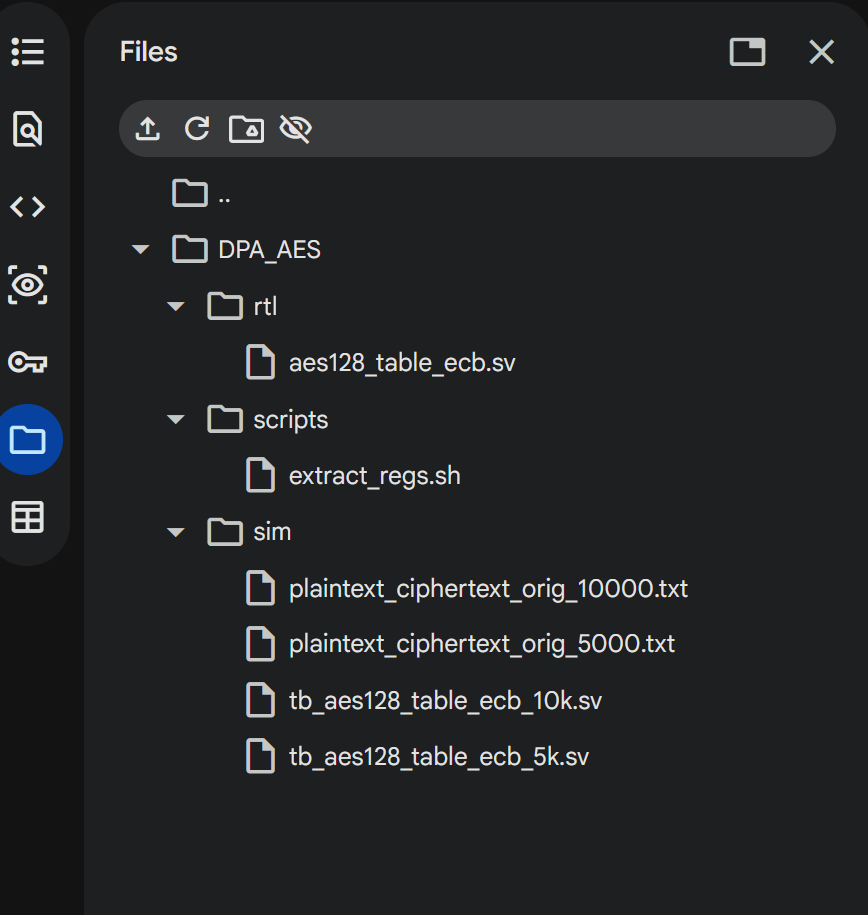

---

## 3 Power Trace Generation

### 3.1 iVerilog: A Verilog Simulator

iVerilog is an open-source Verilog simulator that allows you to simulate and test your hardware designs written in the Verilog Hardware Description Language (HDL). It's a valuable tool for verifying the functionality of your circuits before physical implementation.

**Key Features:**

* **Open-source:**  Freely available and modifiable.
* **Verilog Support:** Supports various Verilog standards, including SystemVerilog.
* **Simulation Capabilities:** Enables functional simulation of digital circuits.
* **Debugging:** Provides debugging tools to identify and fix errors in your designs.

**Common Use Cases:**

* **Verification:**  Test your HDL code for correctness and functionality.
* **Prototyping:**  Simulate hardware designs before implementing them in hardware.
* **Education:**  Learn and practice Verilog coding and simulation.

First, we install iVerilog, select our design and testbench verilog files, then run iVerilog simulation with those. In our case, the design file is AES implementation and the testbench is custom designed one to run AES with a set of plaintexts to generate the output ciphertexts.

#### 3.1.1 Install iVerilog

In [3]:
# Local environment: iverilog was built from source by setup_env.sh
# (no apt/sudo available here), so just put it on PATH for this kernel.
import os, subprocess
IVERILOG_BIN = os.path.abspath(os.path.join("tools", "iverilog", "bin"))
os.environ["PATH"] = IVERILOG_BIN + os.pathsep + os.environ["PATH"]
print(subprocess.run(["iverilog", "-V"], capture_output=True, text=True).stdout.splitlines()[0])


Icarus Verilog version 12.0 (stable) ()


#### 3.1.2 Simulation Commands

We first setup the input files and then call the iverlog simulation command.

##### 3.1.2.1 Select simulation input files

Here we select the simulation files.


*   RTL Design File (AES): ```aes128_table_ecb.sv```
*   Testbench File (for 5k simulations): ```tb_aes128_table_ecb_5k.sv```

5k simulations means 5000 plaintext-cipthertexts are simulated through AES. If you want to run 10000 plaintext-cipthertext simulation, replace ```SIM_File = "DPA_AES/sim/tb_aes128_table_ecb_5k.sv"``` with ```SIM_File = "DPA_AES/sim/tb_aes128_table_ecb_10k.sv"```


In [4]:
RTL_File = "DPA_AES/rtl/aes128_table_ecb.sv"
SIM_File = "DPA_AES/sim/tb_aes128_table_ecb_5k.sv"

##### 3.1.2.2 Run iVerilog simulation

-o : output file,
-g : verilog version

Please note that the simulation takes minutes. `_5k` sim takes around 6 minutes, `_10k` sim around 12 minutes.

This creates 3 outputs,

*   `aes.out`
*   `output.txt`
*   `waveform.vcd`

These outputs, by default, are created in the parent directory, which sits above the `DPA_AES` directory. If you want to save time with simulation (if you need to stop at some point and come back), I would suggest downloading these files, saving them on your computer, and then reuploading them back to Google Colab when you next start working on it again.

You can upload into your Google Colab session by selecting the `Files` tab on the left side, and there will be an Upload Icon on the top (the image under Section 2 has that icon, just above the `DPA_AES` folder, to the left of the Refresh Icon).

Of these files, we're most interested in the VCD file, `waveform.vcd`. This is explained in detail in the next section.

In [5]:
!iverilog -g2012 -o aes.out $RTL_File $SIM_File
!vvp aes.out > output.txt

DPA_AES/rtl/aes128_table_ecb.sv:703: warning: Extra digits given for sized binary constant.
DPA_AES/rtl/aes128_table_ecb.sv:744: warning: Extra digits given for sized binary constant.


### 3.2 VCD Parsing

VCD is a Value Change Dump file. Generally, outputs of RTL simulations are stored as VCD files (dumped from the testbench). This records the starting value of all wires and registers, and all the subsequent changes in their values over the entire simulation duration. VCD files generally record these changes at half clock periods (both edges of a clock). If a value does not change, it is not recorded after the initial value.

We plan to use this VCD file to extract the register values (D-flipflops) from this file and use that to estimate the power trace.

#### 3.2.1 Run the regex script to extract registers from VCD File

The script ```extract_regs.sh```, as the name suggests, extracts the register names from the VCD file. We use regular expressions to find registers in the VCD, extract their names, and then store them into an output file.



Set the input script file, VCD file, and the output register file.

In [6]:
Regex_File = "DPA_AES/scripts/extract_regs.sh" # Script
VCD_File = "waveform.vcd" # VCD
Filtered_Reg_File = "register_file.txt" # Output register file

Run the Bash script.

In [7]:
#Convert the regex script to be executable
!chmod +x $Regex_File

#Extract Registers based on "reg field" in the vcd file and store in a text file
"""
  Script: extract_regs.sh
  Input File: waveform.vcd
  Output File: register_file.txt
"""
!$Regex_File $VCD_File $Filtered_Reg_File

DPA_AES/scripts/extract_regs.sh: line 11: $output_vcd_file: ambiguous redirect


#### 3.2.2 Import Register Names

Now we will import the extracted register names (from the VCD file using the Bash script) into our Python environment.

We will first define the function `extract_register_names` that can read the .txt file and extract the names, and then invoke it.

At the end, `register_list` will contain the list of all extracted registers in our environment.

In [8]:
import re

# Define extract_register_names

def extract_register_names(filename="register_file.txt"):
    """
      Input: register_file.txt
      Output: list of register names
      Description: Extracts each word in the file and adds it to a list
    """
    register_names = []
    try:
        with open(filename, 'r') as file:
            for line in file:
                match = re.search(r"\b(\w+)\b", line) # Matches any whole word

                if match:
                    register_name = match.group(1)
                    register_names.append(register_name)
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
    return register_names

In [9]:
# Invoke extract_register_names

register_list = extract_register_names(Filtered_Reg_File)

#### 3.2.3 Extracting Register VCD

Now, we will use the VCD file to extract the values of the registers as they change during the course of the simulation. This will let us use a Hamming Distance model to then estimate the power consumption of those registers. You could also use a Hamming Weight based model, but I'll leave making changes to that up to the user.

We will install the required packages `matplotlib.pyplot` and `vcdvcd`

`matplotlib.pyplot` is a state-based collection of functions in the Matplotlib library that provides a MATLAB-like interface for creating visualizations in Python. It is the de-facto standard for 2D plotting in data science and engineering.

* **Primary Use Case:** Creating static, interactive, and animated plots (such as line graphs, scatter plots, histograms, and bar charts) to visualize data.
* **How it Works in Colab:** You pass numerical data (like lists or pandas DataFrames) to its plotting functions, customize aesthetic elements like labels, titles, and colors, and then render the visualization directly inline within your notebook cells.

`vcdvcd` is a Python library utilized to parse and analyze **Value Change Dump (VCD)** files. VCD is an industry-standard, text-based file format generated by Electronic Design Automation (EDA) tools (like Verilog or VHDL simulators) that logs the changes in digital signal values over time during hardware simulation.

* **Primary Use Case:** Extracting waveform and signal transition data from digital circuit simulations so it can be verified, analyzed programmatically in Python, or plotted (often by passing the extracted timing data into `matplotlib`).
* **How it Works:** The package reads the VCD file structure, parses the hierarchical variable definitions, and maps out the exact timestamps and logical value transitions (like 0, 1, x, or z) for specified hardware signals.

In [10]:
!pip install vcdvcd matplotlib

Defaulting to user installation because normal site-packages is not writeable


Import the installed packages

In [11]:
import matplotlib.pyplot as plt
from vcdvcd import VCDVCD

Parse the vcd file using VCDVCD. We will get all the signals listed in the vcd file, compare against our set of extracted registers. We do this using `find_matching_signals`.

In [12]:
# Load the VCD file
vcd = VCDVCD(VCD_File)

# Extract available signals
signals = list(vcd.signals)

In [13]:
# Define find_matching_signals to find signals with any value from register_list in their name
def find_matching_signals(signals, register_list):
    """
      Input: signals
             register_list
      Output: list of matching signals
      Description: Finds signals with any value from register_list in their name
    """
    matching_signals = []
    for signal in signals:
        for register in register_list:
            if register in signal:
                #Skipping custom signals used as counters
                if "tb_aes128_table_ecb.dut.itemp" not in signal and "tb_aes128_table_ecb.dut.temp" not in signal:
                  matching_signals.append(signal)
                break # Avoid adding the same signal multiple times if multiple registers match
    return matching_signals

Invoke `find_matching_signals`, with the list stored as `matching_signals`. This list is the exact path to the signal in the VCD (including any modules and submodules it is instantiated in), and its size.

In [14]:
matching_signals = find_matching_signals(signals, register_list)

Creating text file with this `matching_signals` data. The reason we do this is so that you can save this file and not have to run this multiple times. Maybe this was not throught out as well.

In [15]:
# Dump matching_signals to a text file
with open("matching_signals.txt", "w") as f:
    for signal in matching_signals:
        f.write(signal + "\n")

### 3.3 Hamming Distance Multi-Trace Generation

As mentioned in 3.2.3, we'll use Hamming Distance model to estimate the power consumption in registers.


*   First, we'll define the power model. This can be easily replaced with a model of your own (including Hamming Weight mode) if desired.
*   Then, using the extracted registers from 3.2.3, we'll then calculate the total Hamming Distance across the whole trace, giving us the raw power estimate values.
*   However, these values are very discrete (one per clock cycle, as our registers change value at the positive clock edge). This makes it highly unsuitable for analysis. Moreover, a realistic trace won't be so discrete. So, to smoothen this out, we interpolate the power trace to give you a more smoothened version.
*   Finally, we will dump the power trace as a CSV so it can be used for your DPA attack.



#### 3.3.1 Hamming Distance Power Model

Define the Hammind Distance and Hamming Weight power model function. It can be used for both depending on the input HD. By default, we use Hamming Distance.

In [16]:
def compute(prev_value,current_value,HD=True):
    """
      Input: prev_value
              current_value
              hw
      Output: hamming_diff
      Description: Computes the hamming distance between two integers (if HD)
                    or returns the hamming weight value (if not HD)
    """
    diff = 0
    if HD:
      diff = prev_value ^ current_value
    else:
      diff = current_value

    hamming_diff = bin(diff).count('1')  # bit_count() needs Python 3.10+

    return hamming_diff

#### 3.3.2 Power per Register

Using the power model and the extracted registers, we calculate the power for each register.

In [17]:
import numpy as np
from collections import defaultdict

# Dictionary to store the Hamming distance traces for each signal
hamming_diff_traces = {}

# List to store total Hamming distance traces (each entry is a separate trace)
total_hamming_diff_traces = []

# Iterate through matching signals
for signal in matching_signals:
    signal_values = vcd[signal].tv  # Extract signal values over time
    traces = []          # List to store split traces for this signal
    current_trace = []   # Current trace segment
    prev_value = None    # Previous integer value for computing Hamming distance

    for t, v in signal_values:
        # Note: 'x' occurs at dumpoff, so split trace on encountering 'x'
        if 'x' in str(v):
            if current_trace:  # Save the current trace if it has data
                traces.append(current_trace)
                current_trace = []  # Reset for a new trace
            prev_value = None  # Reset previous value for a new trace segment
        else:
            # Convert value to integer
            int_value = int(v,2)
            if prev_value is None:
                # First value in a trace: no previous value so distance is 0
                hamming_diff = 0
            else:
                # Compute Hamming distance as the number of differing bits
                hamming_diff = compute(prev_value, int_value, True)

            prev_value = int_value  # Update previous value

            # Append the (time, Hamming distance) to the current trace
            current_trace.append((t, hamming_diff))

    # Save the last trace if it has data
    if current_trace:
        traces.append(current_trace)

    # Store traces for the current signal
    hamming_diff_traces[signal] = traces

#### 3.3.3 Total power

Combine (sum) individual signals into global total traces

In [18]:
# Determine the maximum number of trace segments across all signals.
max_traces = max(len(traces) for traces in hamming_diff_traces.values())

# Create a list of global total traces.
# Each element is a defaultdict (keyed by timestamp) that will accumulate Hamming distances.
total_hamming_diff_traces = [defaultdict(int) for _ in range(max_traces)]

# For each signal, add its trace segment values to the corresponding global trace.
for signal, traces in hamming_diff_traces.items():
    for i, trace in enumerate(traces):
        for t, diff in trace:
            total_hamming_diff_traces[i][t] += diff

# Convert each global trace dictionary into sorted lists for plotting.
global_traces = []
for trace_dict in total_hamming_diff_traces:
    sorted_timestamps = sorted(trace_dict.keys())
    sorted_diffs = [trace_dict[t] for t in sorted_timestamps]
    global_traces.append((sorted_timestamps, sorted_diffs))

#### 3.3.4 Interpolating Generated Trace

UnivariateSpline interpolation of the per-clock-cycle power trace.

In [19]:
from scipy.interpolate import UnivariateSpline
# List to store interpolated global traces
# Each element is a tuple: (new_timestamps, new_diffs)
interpolated_global_traces = []

# Iterate over all traces in global_traces to interpolate them
for timestamps, diffs in global_traces[0:-1]:
    # Set a smoothing factor based on variance and number of points (adjust as needed)
    smoothing_factor = 0.1 * np.var(diffs) * len(timestamps)

    # Create the smoothing spline for the current trace
    spline = UnivariateSpline(timestamps, diffs, s=smoothing_factor)

    # Create a new, evenly spaced time axis for interpolation (e.g., 1000 points)
    new_timestamps = np.linspace(min(timestamps), max(timestamps), 1000)
    new_diffs = spline(new_timestamps)

    # Store the interpolated results
    interpolated_global_traces.append((new_timestamps, new_diffs))

####3.3.5 Dumping interpolated traces as a CSV

We dump the generated power trace into a CSV file for easy access and future analysis that you will be doing. You should find the generated power trace CSV file (`interpolated_traces_no_timestamps.csv`) in the `FILES` tab. You may want to save it so you don't have to run all the steps above.

In [20]:
Trace_File = "interpolated_traces_no_timestamps.csv"

In [21]:
import csv

# Prepare data for CSV
csv_data = []
for timestamps, diffs in interpolated_global_traces:
    csv_data.append(diffs)  # Only diffs as no timestamps required

# Write to CSV
with open(Trace_File, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(csv_data)


### 3.5 Observing Hamming Distance of individual signals

Choose the signal you would like to plot!
Below is a example so you can observe what the power trace of an individual signal will look like. This is just for your information, and realistically, you will not be able to see this on hardware. You will only be able to measure the total power trace.


Tip: matching_signals.txt has the names of sigals you would be interested in.

`signal_to_plot` is the signal for which you want to plot the power trace.


In [22]:
signal_to_plot = 'tb_aes128_table_ecb.clk_reg'

Plotting Hamming Distance of the chosen signal.

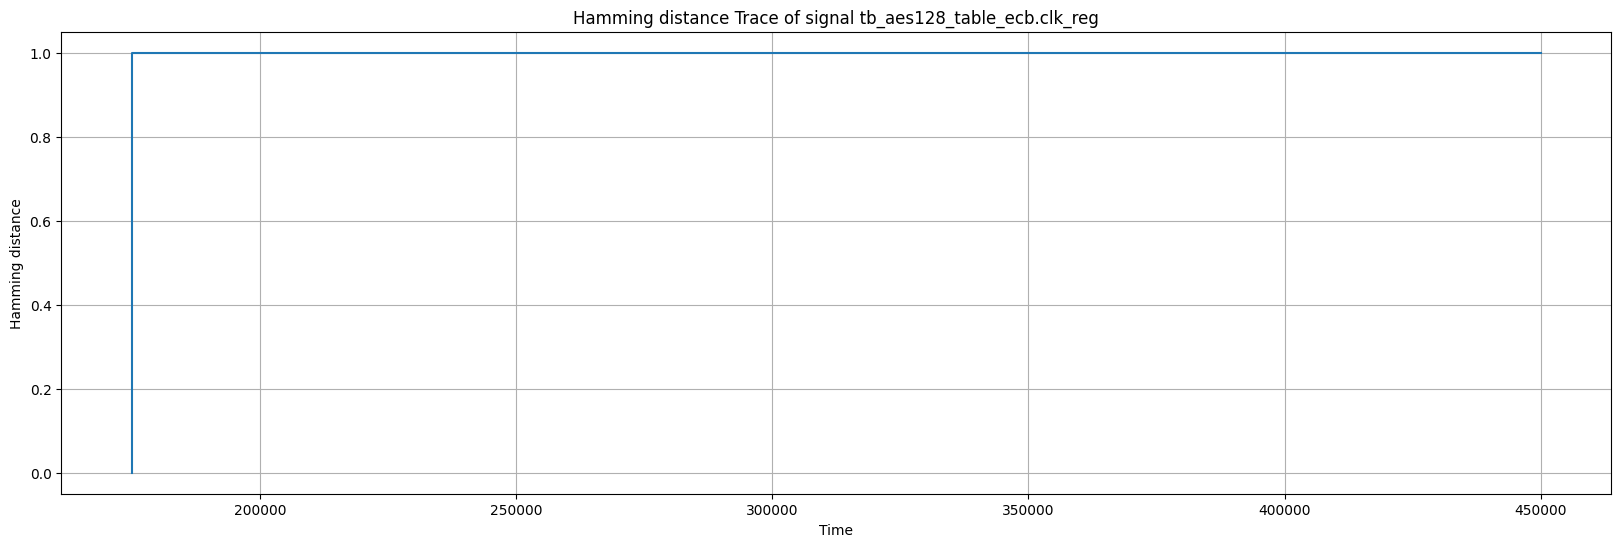

In [23]:
times, weights = zip(*hamming_diff_traces[signal_to_plot][0])
plt.figure(figsize=(20, 6))
plt.step(times, weights)
plt.xlabel("Time")
plt.ylabel("Hamming distance")
plt.title(f"Hamming distance Trace of signal {signal_to_plot}")
plt.grid(True)
plt.show()

---

## 4 DPA

Now, you will start performing the DPA attack. Obviously, most of the DPA code is not in here. You will have to figure that out. However, we have a few helper functions that will let you work with the environment we have provided you.

### 4.1 Importing Power Trace

Import a CSV power trace. into your environment.

In [24]:
import pandas as pd
df = pd.read_csv(Trace_File,header=None)

### 4.2 Importing CipherText and PlainText

Importing the `5000` plaintext and ciphertext. If you are working with the `10000` pair version, you will have to change the name of the file below. When you rin the code snipper below,

*   `lines` will be the list containing plaintext values.

*   `lines2` will be the list containing ciphertext values.

Change the names for your convenience if needed.

In [25]:
lines = []
lines2 = []
with open("DPA_AES/sim/plaintext_ciphertext_orig_5000.txt", "r") as f:
    for line in f:
        plaintext, ciphertext = line.strip().split("_")
        lines.append(plaintext)
        lines2.append(ciphertext)

import numpy as np
ciphertexts = np.array([list(bytes.fromhex(c)) for c in lines2], dtype=np.uint8)  # (N, 16) byte array
print(ciphertexts.shape)


(5000, 16)


### 4.3 Trace Overview

The image below is the waveform for a single AES Encryption.

It is essential to note that the Verilog code that we use for each AES encryption behaves in a predictable manner.


1.   It first starts with a Reset phase `Reset Asserted` in the figure.
2.   Round-0 (the first red box from the left side) occurs during the Key Expansion phase, as the Key for Round-0 is the secret key, but for future rounds, you need a transformed version of the secret key.
3.   Only after the full Key Expansion is complete does Round-1 start (2nd red box from the left), followed by all other rounds consecutively (red boxes), one per clock cycle.
4.   Ideally, you want to analyze the trace during the blue arrow, as the includes all the rounds of AES. It does, however, also include Key Expansion (during Round-0), so keep that in mind.

Due to its peculiar nature, I would suggest you refer back to this as you are going through some of the tasks below for the assignment, so you can figure out how and where to attack the power trace.


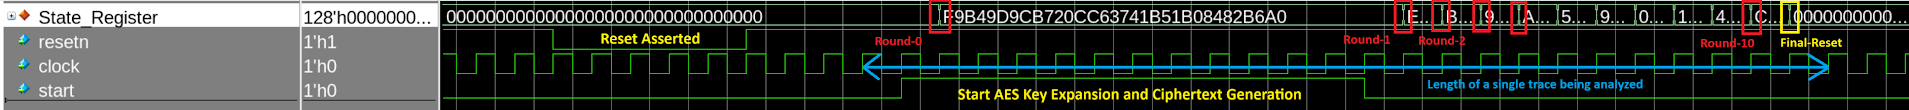

Note: Right click on the image and open in new tab for a larger view

### 4.4 Assignment

Below is the assignment section, where you will progressively work through performing a DPA attack. There are 3 tasks, and each task has multiple subtasks. The questions are numbered as **Question 1**, **Question 2**, etc. There are also some figure that are required for the assignment, and are marked as `Figure 1`, `Figure 2`, etc.

#### 4.4.1 Task 1 - Analyzing the power trace


##### 4.4.1.1 Subtask A

Plot the first power trace (Figure 1), corresponding to the first encryption operation.

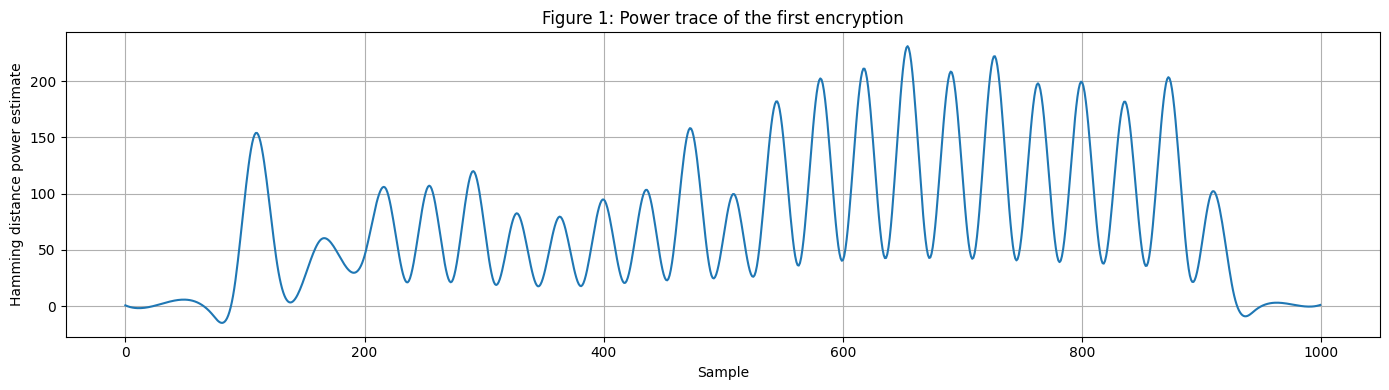

In [26]:
import matplotlib.pyplot as plt

trace = df.values  # convert the CSV DataFrame (loaded in 4.1) into a plain array

plt.figure(figsize=(14, 4))          # was "figuresize" - typo
plt.plot(trace[0])                   # trace[0] = first encryption's power trace
plt.xlabel("Sample")
plt.ylabel("Hamming distance power estimate")
plt.title("Figure 1: Power trace of the first encryption")
plt.grid(True)
plt.tight_layout()
plt.savefig("figure1_first_trace.png", dpi=120)
plt.show()


##### 4.4.1.2 Subtask B

**Question 1.** Analyze the power trace you plotted in Task 1 (Figure 1). What are the peaks in the trace? How is AES implemented?

My answer: 22 peaks.
Peaks 1 through 11 seem to be before any encryption starts. FSM starts 11 clock cycles computing the entire key schedule which is independent of the plaintext. 
Peaks 12 through 22 now seems to have state_reg_9 .. 3 update every cycle too simultaneously while computing the key schedule. 12 through 22 seem to be actual encryption with mixcolumns mixing bits around.
Last peak is probably round 10 that skips mixcolumns.


Hint: Compare the trace against the waveform above to see what the peaks correspond to.

##### 4.4.1.3 Subtask C

Before we proceed to DPA, think of a good pre-processing step to make the attack more successful.

My answer: If traces are misaligned then correlating across traces would smear the real signal. A good pre processing step would be trace alignment and making sure or checking if every trace lines up sample for sample.

Hint: Plot the first few
power traces and think how to better align them.

#### 4.4.2 Task 2 - Performing the DPA attack



##### 4.4.2.1 Subtask A

Let's execute the DPA attack using Pearson's correlation test. First, think of an easy target operation for the DPA and, second, consider the number of bits to be estimated by DPA at a time.

My answer: Lets target the lsat round using the know ciphertext. Round 10 doesn't seem to use mixcolumns so the output byte depends on exactly one s box ooutput and one round 10 key per byte which makes it a lot more simple. 

In [27]:

SBOX = [
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16,
]  # same table as the RTL's subbytes.s_box function
INV_SBOX = [0] * 256
for idx, val in enumerate(SBOX):
    INV_SBOX[val] = idx
SBOX = np.array(SBOX, dtype=np.uint8)
INV_SBOX = np.array(INV_SBOX, dtype=np.uint8)
RCON = [0x01,0x02,0x04,0x08,0x10,0x20,0x40,0x80,0x1b,0x36]

def reverse_map(i):
    col, row = i // 4, i % 4
    return 4 * ((col + row) % 4) + row

def hw(x):
    return np.unpackbits(np.asarray(x, dtype=np.uint8).reshape(-1, 1), axis=1).sum(axis=1)

def pearson_corr_matrix(hyp, tr):
    hyp = hyp.astype(np.float64); tr = tr.astype(np.float64)
    hyp_c = hyp - hyp.mean(axis=0, keepdims=True)
    tr_c = tr - tr.mean(axis=0, keepdims=True)
    num = hyp_c.T @ tr_c
    denom = np.outer(np.sqrt((hyp_c**2).sum(axis=0)), np.sqrt((tr_c**2).sum(axis=0)))
    return num / (denom + 1e-12)

##### 4.4.2.2 Subtask B

**Question 2.** What is a good power model for the target operation? Justify it.

My answer for this would be hamming distance. It counts how many bit flips between a registers old value and new value. For round 10, old value is the unknown pre final round byte and new value is the know ciphertext byte. We can guess the key and use it to compute a candidate for the old value and count the hamming distance. I tried the simpler model but the real key was hard to decipher from the noise. 

Note: Feel free to use either Hamming Weight or Hamming Distance before you commit to one.

Change the call to compute function accordingly in section 3.3. You may also try by causing an intentinal mismatch between generated trace's and your DPA's power model to observe its effects.

In [28]:
RUN_DIR_5K = "run5k"
ciphertexts_5k = ciphertexts  # from section 4.2, RUN_DIR="run5k"

def cpa_attack(ciphertexts_arr, trace_arr):
    """Return recovered K10 (16 bytes) and full (256, T) corr matrices per byte."""
    recovered = np.zeros(16, dtype=np.uint8)
    all_corr = []
    for i in range(16):
        j = reverse_map(i)
        ct_i = ciphertexts_arr[:, i]
        ct_j = ciphertexts_arr[:, j]
        guesses = np.arange(256, dtype=np.uint8)
        s9_hyp = INV_SBOX[ct_i[:, None] ^ guesses[None, :]]          # (N,256)
        model = hw((s9_hyp ^ ct_j[:, None]).reshape(-1)).reshape(s9_hyp.shape)
        corr = pearson_corr_matrix(model, trace_arr)                 # (256,T)
        peak = np.max(np.abs(corr), axis=1)
        recovered[i] = np.argmax(peak)
        all_corr.append(corr)
    return recovered, all_corr

recovered_k10_5k, corr_5k = cpa_attack(ciphertexts_5k, trace)
print("Recovered K10 (5000 traces):", recovered_k10_5k.tobytes().hex())

Recovered K10 (5000 traces): 13111d7fe3944a17f307a78b4d2b30c5


##### 4.4.2.3 Subtask C

Apply the DPA on the first byte of the key, plot the results (Figure 2) for all key guesses.


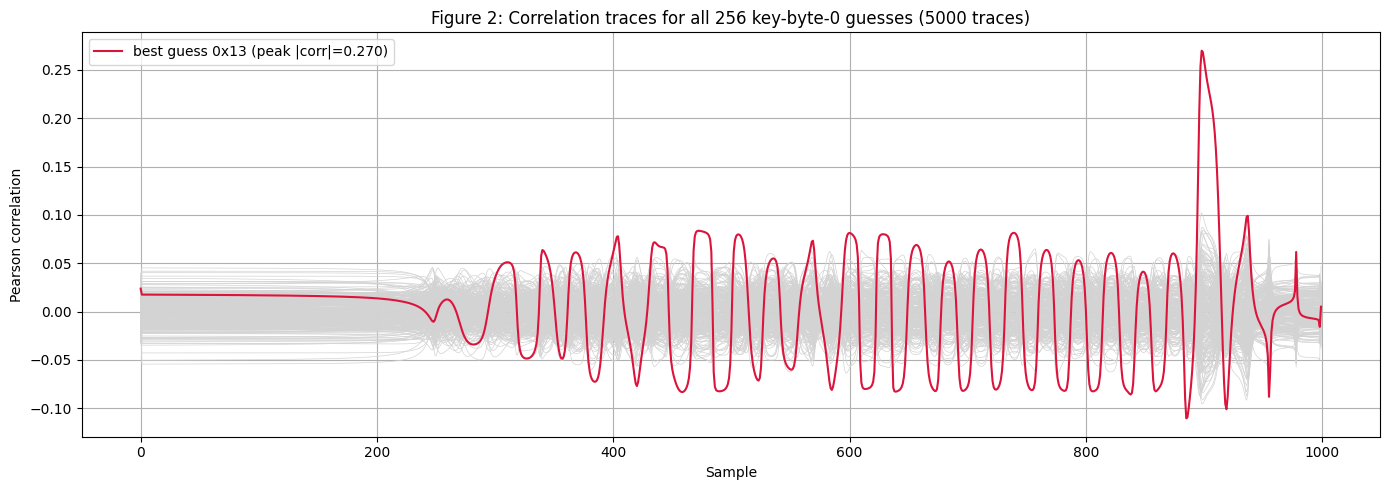

In [29]:
byte0_corr = corr_5k[0]                       # (256, 1000)
peak_per_guess = np.max(np.abs(byte0_corr), axis=1)
best_guess = int(np.argmax(peak_per_guess))

plt.figure(figsize=(14, 5))
for g in range(256):
    plt.plot(byte0_corr[g], color="lightgray", linewidth=0.5)
plt.plot(byte0_corr[best_guess], color="crimson", linewidth=1.5,
         label=f"best guess 0x{best_guess:02x} (peak |corr|={peak_per_guess[best_guess]:.3f})")
plt.xlabel("Sample")
plt.ylabel("Pearson correlation")
plt.title("Figure 2: Correlation traces for all 256 key-byte-0 guesses (5000 traces)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figure2_all_guesses_byte0.png", dpi=120)
plt.show()

##### 4.4.2.4 Subtask D

Find the maximum correlation (consider both positive and negative peaks) and plot the two best key guesses (Figure 3) that have the maximum likelihood.

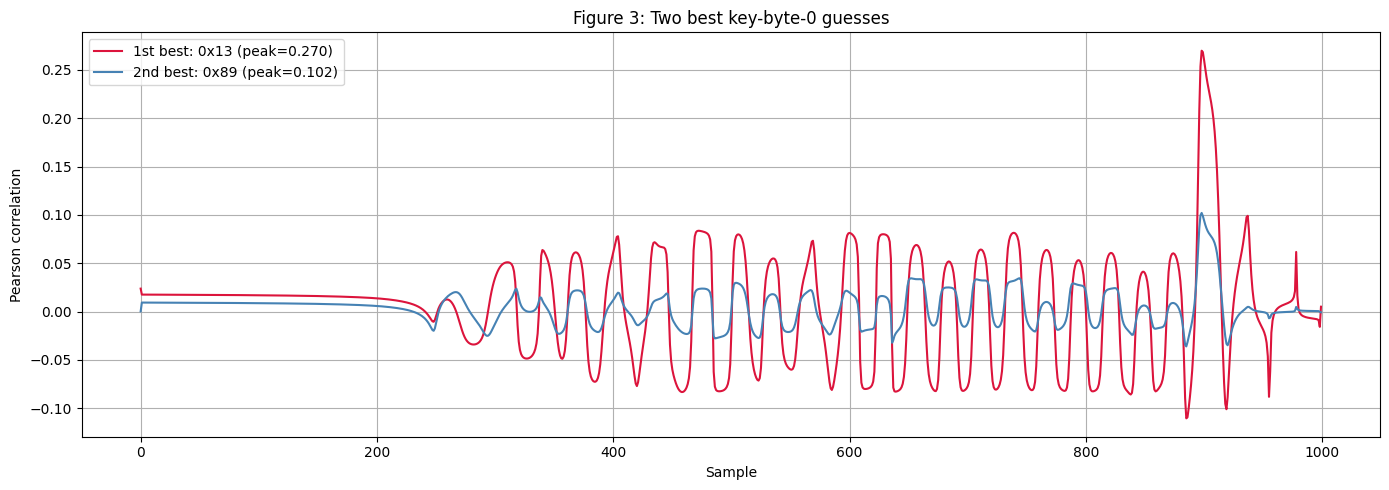

1st: 0x13 peak=0.2699   2nd: 0x89 peak=0.1020


In [30]:
order = np.argsort(peak_per_guess)[::-1]
best, second = order[0], order[1]

plt.figure(figsize=(14, 5))
plt.plot(byte0_corr[best], label=f"1st best: 0x{best:02x} (peak={peak_per_guess[best]:.3f})", color="crimson")
plt.plot(byte0_corr[second], label=f"2nd best: 0x{second:02x} (peak={peak_per_guess[second]:.3f})", color="steelblue")
plt.xlabel("Sample")
plt.ylabel("Pearson correlation")
plt.title("Figure 3: Two best key-byte-0 guesses")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figure3_two_best_byte0.png", dpi=120)
plt.show()
print(f"1st: 0x{best:02x} peak={peak_per_guess[best]:.4f}   2nd: 0x{second:02x} peak={peak_per_guess[second]:.4f}")

##### 4.4.2.5 Subtask E

**Question 3.** Considering the two cases from above (4.4.2.4) , which one is more likely to be the correct key guess? Why do you specifically see these two results?

Im thinking whichever guess has the largest magnitude and stands clearly above the noise is the strongest guess. Im seeing these two results because a wrong guess can correlate strongly in the opposite direction just by how the bits interact. With that I have to checkboth the positive and negative candidates in magnitude and pick whichever one is the biggest.



In [31]:
signed_peak = byte0_corr[np.arange(256), np.argmax(np.abs(byte0_corr), axis=1)]
top_pos = np.argsort(signed_peak)[::-1][:3]
top_neg = np.argsort(signed_peak)[:3]
print("most positive:", [(hex(g), round(float(signed_peak[g]), 4)) for g in top_pos])
print("most negative:", [(hex(g), round(float(signed_peak[g]), 4)) for g in top_neg])

most positive: [('0x13', 0.2699), ('0x89', 0.102), ('0x59', 0.0951)]
most negative: [('0xd4', -0.0955), ('0x9d', -0.0918), ('0x3b', -0.0913)]


##### 4.4.2.6 Subtask F

**Question 4.** What is the maximum leak point? Since you are working with an interpolated power trace without timestamp data, a sample number would work.



In [32]:
best_sample = int(np.argmax(np.abs(byte0_corr[best_guess])))
print(f"Max-leak sample: {best_sample} / 1000")

Max-leak sample: 898 / 1000


In [33]:
RUN_DIR_10K = "run10k"
trace_10k = pd.read_csv(f"{RUN_DIR_10K}/trace.csv", header=None).values
lines10, lines2_10 = [], []
with open(f"{RUN_DIR_10K}/DPA_AES/sim/plaintext_ciphertext_orig_10000.txt") as f:
    for line in f:
        p, c = line.strip().split('_')
        lines10.append(p); lines2_10.append(c)
ciphertexts_10k = np.array([list(bytes.fromhex(c)) for c in lines2_10], dtype=np.uint8)
print("10k trace shape:", trace_10k.shape, " ciphertexts:", ciphertexts_10k.shape)

10k trace shape: (10000, 1000)  ciphertexts: (10000, 16)


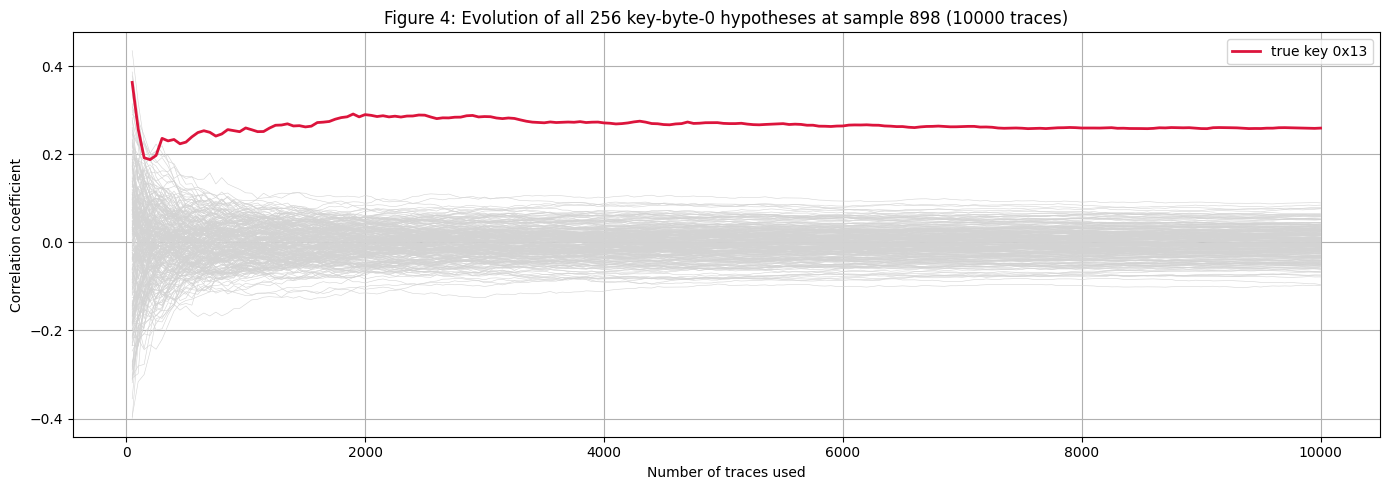

In [34]:
LEAK_SAMPLE = best_sample  # 898, consistent across both datasets and all 16 bytes
byte_index = 0
j = reverse_map(byte_index)
ct_i, ct_j = ciphertexts_10k[:, byte_index], ciphertexts_10k[:, j]
guesses = np.arange(256, dtype=np.uint8)
s9_hyp_10k = INV_SBOX[ct_i[:, None] ^ guesses[None, :]]
model_10k = hw((s9_hyp_10k ^ ct_j[:, None]).reshape(-1)).reshape(s9_hyp_10k.shape)  # (10000, 256)
leak_trace_10k = trace_10k[:, LEAK_SAMPLE]

trace_counts = np.arange(50, 10001, 50)
evolution = np.zeros((len(trace_counts), 256))
for idx, n in enumerate(trace_counts):
    m = model_10k[:n]; t = leak_trace_10k[:n]
    m_c = m - m.mean(axis=0, keepdims=True); t_c = t - t.mean()
    num = m_c.T @ t_c
    denom = np.sqrt((m_c**2).sum(axis=0)) * np.sqrt((t_c**2).sum())
    evolution[idx] = num / (denom + 1e-12)

true_k10_byte0 = 0x13  # confirmed in Subtask H below
plt.figure(figsize=(14, 5))
for g in range(256):
    plt.plot(trace_counts, evolution[:, g], color="lightgray", linewidth=0.4)
plt.plot(trace_counts, evolution[:, true_k10_byte0], color="crimson", linewidth=2,
         label=f"true key 0x{true_k10_byte0:02x}")
plt.xlabel("Number of traces used")
plt.ylabel("Correlation coefficient")
plt.title(f"Figure 4: Evolution of all 256 key-byte-0 hypotheses at sample {LEAK_SAMPLE} (10000 traces)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figure4_evolution_10k.png", dpi=120)
plt.show()

##### 4.4.2.7 Subtask G

**Question 5.** Starting at how many traces, does the key guess with maximum correlation show highest correlation?

My answerL N = 300 traces, 

In [35]:
stable_n = None
for idx, n in enumerate(trace_counts):
    if np.argmax(np.abs(evolution[idx])) == true_k10_byte0:
        if all(np.argmax(np.abs(evolution[k])) == true_k10_byte0 for k in range(idx, len(trace_counts))):
            stable_n = n
            break
print(f"The correct key guess (0x{true_k10_byte0:02x}) started at N = {stable_n} traces.")

The correct key guess (0x13) started at N = 300 traces.


##### 4.4.2.8 Subtask H

**Question 6.** Apply the DPA on the entire key. **What is the 128-bit AES
secret key?**

Note that not all key values can be 100% detected depending on your targeted computation, i.e. there can be false positives. If this is the case, you may need to take the first n possible results and apply a brute-force search within these reduced search space.

Hint: Targeting the initialization may
especially cause this behavior, targeting computations after the initialization might be a better idea. You can also try the partition-based tests (with difference of means) to extract the key.

My answer: The recovered 128 bit aes secret key is 
00 01 02 03 04 05 06 07 08 09 0a 0b 0c 0d 0e 0f



In [36]:
def inv_key_schedule(k10_bytes):
    words = [None] * 44
    for w in range(4):
        words[40 + w] = k10_bytes[4*w:4*w+4].copy()
    for r in range(10, 0, -1):
        base = r * 4
        for i in range(3, 0, -1):
            words[base + i - 4] = words[base + i] ^ words[base + i - 1]
        prev = words[base - 1]
        temp = np.array([prev[1], prev[2], prev[3], prev[0]], dtype=np.uint8)
        temp = SBOX[temp]
        temp[0] ^= RCON[r - 1]
        words[base - 4] = words[base] ^ temp
    return [np.concatenate(words[4*r:4*r+4]) for r in range(11)]

print("Recovered K10:", recovered_k10_5k.tobytes().hex())
round_keys = inv_key_schedule(recovered_k10_5k)
recovered_k0 = round_keys[0]
print("Recovered K0:", recovered_k0.tobytes().hex())

Recovered K10: 13111d7fe3944a17f307a78b4d2b30c5
Recovered K0: 000102030405060708090a0b0c0d0e0f


#### 4.4.3 Task 3 - Evaluating the DPA attack



##### 4.4.3.1 Subtask A

**Question 7.** What is the mean time to disclosure, i.e. average number of traces required to extract the key for your DPA attack? To find this average, you need to estimate starting at how many measurement the targeted secret key portion leaks and average this value for all parts. If the key cannot be correctly estimated for a particular key part, you can use the maximum number of measurements (i.e. 10000) for that part.

My answer: For each of the 16 key bytes we find the smallest N at which that bytes correct guess first becomes the top guess


In [37]:
mtd_per_byte = []
for i in range(16):
    j = reverse_map(i)
    ct_i, ct_j = ciphertexts_10k[:, i], ciphertexts_10k[:, j]
    s9_hyp_i = INV_SBOX[ct_i[:, None] ^ guesses[None, :]]
    model_i = hw((s9_hyp_i ^ ct_j[:, None]).reshape(-1)).reshape(s9_hyp_i.shape)
    leak_i = trace_10k[:, LEAK_SAMPLE]
    true_byte = recovered_k10_5k[i]  # cross-check target: the byte value this same attack recovered

    mtd = 10000
    for n in trace_counts:
        m = model_i[:n]; t = leak_i[:n]
        m_c = m - m.mean(axis=0, keepdims=True); t_c = t - t.mean()
        num = m_c.T @ t_c
        denom = np.sqrt((m_c**2).sum(axis=0)) * np.sqrt((t_c**2).sum())
        corr_n = num / (denom + 1e-12)
        if np.argmax(np.abs(corr_n)) == true_byte:
            mtd = n
            break
    mtd_per_byte.append(mtd)
    print(f"byte {i:2d}: MTD = {mtd}")

mean_mtd = np.mean(mtd_per_byte)
print(f"\nMean time to disclosure across all 16 key bytes: {mean_mtd:.0f} traces")

byte  0: MTD = 300
byte  1: MTD = 1050


byte  2: MTD = 900
byte  3: MTD = 500
byte  4: MTD = 600


byte  5: MTD = 400
byte  6: MTD = 850


byte  7: MTD = 350
byte  8: MTD = 150
byte  9: MTD = 1350


byte 10: MTD = 250
byte 11: MTD = 350


byte 12: MTD = 1850


byte 13: MTD = 550
byte 14: MTD = 1350


byte 15: MTD = 750

Mean time to disclosure across all 16 key bytes: 722 traces


##### 4.4.3.2 Subtask B

**Question 8.** Compare this with the theoretical cryptanalysis (i.e. brute-force attack) of AES, what is the reduction ratio in the number of traces required to break AES? Why is DPA so powerful?

My answer:
Brute force would need about 2^127 attempts to find 128 bit key and about 1.7*10^38 guesses. This DPA attack only needed 10^2 - 10^3 power traces to recover the entire key which is a lot better. About ~10^35.7 in reduction rnatio.

DPA is powerful because it doesnt treat the 128 bit key as one giant unknown thing but targets a 8 bit operation at a time so we can slowly isolate every byte during every round.

In [38]:
import math
brute_force_keyspace = 2**128
mtd = mean_mtd
reduction_ratio = brute_force_keyspace / mtd
print(f"Brute force: 2^128 = {brute_force_keyspace:.3e}")
print(f"DPA mean time to answer: {mtd:.0f} traces")
print(f"Reduction ratio: {reduction_ratio:.3e}  (~10^{math.log10(reduction_ratio):.1f})")

Brute force: 2^128 = 3.403e+38
DPA mean time to answer: 722 traces
Reduction ratio: 4.714e+35  (~10^35.7)


#### 4.4.4 Bonus Question(s)

##### 4.4.4.1 Subtask A

**Question 9 (Bonus).** Did you use AI in any form to complete the assignment? You can copy-paste code from the internet but you need to specify which parts you retrieved and which parts you wrote in your report. If you write the entire code yourself, you get an extra 12.5 points (out of 100) added on your score.

##### 4.4.4.2 Subtask B

This question is worth **0** points. This is to aid our research in the effectiveness of this assignment, and all data will be anonymized. You may choose to not complete this question and you will not be penalized for it. Nor will you get any bonus points for completing this question. This is completely voluntary and has no effect on the score for this assignment, future assignments, and the course grade.

You will also be given a consent form to use anonymized data from the rest of the assignment to guage the effectiveness of this assignment, if it has already not been done so. Again, that will have more detailed version of the voluntary nature of it, but you will not be penalized in any manner for not providing consent.

**Question 10 (Optional).** How long did it take for you to complete questions 1 to 8?